In [6]:
!ls -lh

total 624K
-rw-r--r-- 1 root root 606K Dec 22 12:35 Corn_Cultivated_Soil_Tested_Data_REALISTIC_+200_2019_sorted.csv
-rw-r--r-- 1 root root  12K Dec 22 12:31 Maize_Yield_Prediction_Starter_Colab.ipynb
drwxr-xr-x 1 root root 4.0K Dec 11 14:34 sample_data


In [7]:
import pandas as pd

DATA_PATH = "/content/Corn_Cultivated_Soil_Tested_Data_REALISTIC_+200_2019_sorted.csv"


In [8]:
df = pd.read_csv(DATA_PATH)
print(df.shape)

(2923, 28)


In [9]:
df.head()

,district,location,season,planting_date,planting_month,field_size_ha,first_fert_date,second_fert_date,seed_variety,soil_type,...,sunshine_hours,soil_ph,soil_nitrogen_n,soil_phosphorus_p,soil_potassium_k,soil_fertility_index,n_status_class,p_status_class,k_status_class,yield_t_ha
0,Badulla,Rideemaliyadda,Maha,1/5/2019,1,2.541,1/26/2019,2/10/2019,Local Variety,RBE,...,6.765,6.472,54.338,6.734,253.324,0.580,Medium,Low,High,4.2885
1,Badulla,Rideemaliyadda,Maha,1/23/2019,1,1.029,2/13/2019,3/2/2019,Commando,RYP,...,7.396,6.124,50.404,21.642,224.904,0.650,Medium,High,High,4.4575
2,Anuradhapura,Horowpathana,Maha,1/27/2019,1,1.795,2/20/2019,3/22/2019,Local Variety,RBE,...,7.166,6.440,74.092,6.918,255.639,0.644,Medium,Low,High,4.7621
3,Matale,Pelwehera,Maha,2/8/2019,2,1.368,3/3/2019,3/31/2019,Jet 999,RBE,...,8.367,6.307,78.431,14.137,70.034,0.519,Medium,Medium,Low,4.6565
4,Monaragala,Wellawaya,Maha,2/8/2019,2,1.632,2/23/2019,3/23/2019,Commando,RYP,...,8.290,5.980,83.108,9.199,206.377,0.600,Medium,Low,High,5.1971


# Understand the Dataset

In [10]:
print("Total columns:", len(df.columns))
for c in df.columns:
    print(c)

Total columns: 28
district
location
season
planting_date
planting_month
field_size_ha
first_fert_date
second_fert_date
seed_variety
soil_type
soil_condition
irrigation_type
rainfall_condition
rainfall_30d_mm
seasonal_rainfall_mm
avg_temperature_c
max_temperature_c
avg_humidity_pct
sunshine_hours
soil_ph
soil_nitrogen_n
soil_phosphorus_p
soil_potassium_k
soil_fertility_index
n_status_class
p_status_class
k_status_class
yield_t_ha


> ***Check data types***



In [11]:
df.dtypes

,0
district,object
location,object
season,object
planting_date,object
planting_month,int64
field_size_ha,float64
first_fert_date,object
second_fert_date,object
seed_variety,object
soil_type,object


> ***Check missing values***



In [12]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
planting_month,2923.0,7.337667,3.122950,1.000,4.0000,9.0000,10.0000,12.000
field_size_ha,2923.0,1.808732,0.729029,0.500,1.2100,1.8110,2.4100,3.500
rainfall_30d_mm,2923.0,308.116460,96.514966,36.232,234.3540,300.7000,372.2655,590.007
seasonal_rainfall_mm,2923.0,829.973980,192.334877,465.666,674.0385,820.5070,990.9840,1241.201
avg_temperature_c,2923.0,27.572845,2.051008,22.902,25.9025,27.5970,29.1570,32.502
max_temperature_c,2923.0,31.716681,2.315490,25.547,29.9970,31.7030,33.3990,38.384
avg_humidity_pct,2923.0,72.919595,7.180239,56.603,67.2960,73.0020,78.6035,92.005
sunshine_hours,2923.0,7.493152,1.138420,4.757,6.6040,7.4990,8.3980,10.367
soil_ph,2923.0,6.250016,0.324093,5.301,6.0315,6.2520,6.4680,7.417
soil_nitrogen_n,2923.0,70.163414,27.598895,9.895,47.2540,69.5090,92.7650,125.009


from matplotlib import pyplot as plt
_df_0['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['std'].plot(kind='hist', bins=20, title='std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['25%'].plot(kind='hist', bins=20, title='25%')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['count']
  ys = series['25%']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_27.sort_values('count', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('count')
_ = plt.ylabel('25%')

from matplotlib import pyplot as plt
_df_28['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_29['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_30['min'].plot(kind='line', figsize=(8, 4), title='min')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_31['25%'].plot(kind='line', figsize=(8, 4), title='25%')
plt.gca().spines[['top', 'right']].set_visible(False)



> ***Target variable check (yield) distribution***



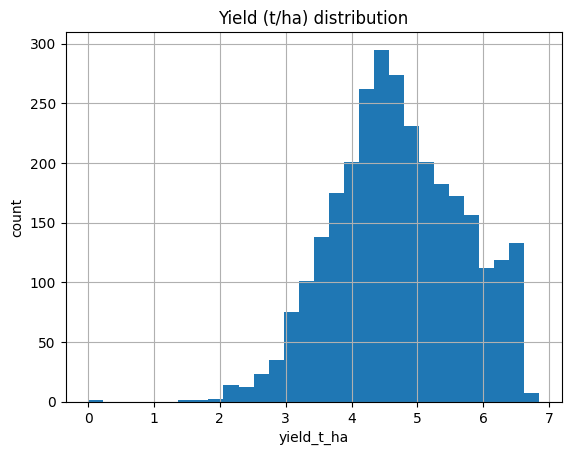

Yield min: 0.0
Yield max: 6.85
Yield mean: 4.719267943893261


In [14]:
import matplotlib.pyplot as plt

plt.figure()
df["yield_t_ha"].hist(bins=30)
plt.title("Yield (t/ha) distribution")
plt.xlabel("yield_t_ha")
plt.ylabel("count")
plt.show()

print("Yield min:", df["yield_t_ha"].min())
print("Yield max:", df["yield_t_ha"].max())
print("Yield mean:", df["yield_t_ha"].mean())

In [15]:
print("Districts:", sorted(df["district"].unique()))
print("Seed varieties:", sorted(df["seed_variety"].unique()))
print("Seasons:", sorted(df["season"].unique()))

Districts: ['Ampara', 'Anuradhapura', 'Badulla', 'Matale', 'Monaragala']
Seed varieties: ['Commando', 'GT 200', 'GT 709', 'Jet 999', 'Local Variety', 'Pacific 808']
Seasons: ['Maha', 'Yala']


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
bad_temp = df[df["max_temperature_c"] < df["avg_temperature_c"]]
print("Rows with max_temperature_c < avg_temperature_c:", len(bad_temp))
bad_temp[["avg_temperature_c","max_temperature_c"]].head(10)

Rows with max_temperature_c < avg_temperature_c: 2


,avg_temperature_c,max_temperature_c
602,28.900,28.592
776,25.799,25.547


In [18]:
import pandas as pd

tmp = df.copy()
tmp["planting_date_dt"] = pd.to_datetime(tmp["planting_date"], format="%m/%d/%Y", errors="coerce")
tmp["first_fert_dt"] = pd.to_datetime(tmp["first_fert_date"], format="%m/%d/%Y", errors="coerce")
tmp["second_fert_dt"] = pd.to_datetime(tmp["second_fert_date"], format="%m/%d/%Y", errors="coerce")

bad_first = tmp[tmp["first_fert_dt"] < tmp["planting_date_dt"]]
bad_second = tmp[tmp["second_fert_dt"] < tmp["first_fert_dt"]]

print("First fert before planting:", len(bad_first))
print("Second fert before first fert:", len(bad_second))

First fert before planting: 2
Second fert before first fert: 0


In [19]:
checks = {
    "soil_ph_out_of_range": ((df["soil_ph"] < 3.5) | (df["soil_ph"] > 9.0)).sum(),
    "humidity_out_of_range": ((df["avg_humidity_pct"] < 0) | (df["avg_humidity_pct"] > 100)).sum(),
    "negative_rainfall_30d": (df["rainfall_30d_mm"] < 0).sum(),
    "negative_seasonal_rainfall": (df["seasonal_rainfall_mm"] < 0).sum(),
    "negative_yield": (df["yield_t_ha"] < 0).sum(),
    "field_size_too_small": (df["field_size_ha"] < 0.05).sum(),
}
checks

{'soil_ph_out_of_range': np.int64(0),
 'humidity_out_of_range': np.int64(0),
 'negative_rainfall_30d': np.int64(0),
 'negative_seasonal_rainfall': np.int64(0),
 'negative_yield': np.int64(0),
 'field_size_too_small': np.int64(0)}

# Data Cleaning



> ***Data Cleaning + Feature Engineering***



In [21]:
df2 = df.copy()
print(df2.shape)

(2923, 28)


In [24]:
#Convert date columns to datetime
import pandas as pd

df2["planting_date_dt"] = pd.to_datetime(df2["planting_date"], format="%m/%d/%Y", errors="coerce")
df2["first_fert_dt"]    = pd.to_datetime(df2["first_fert_date"], format="%m/%d/%Y", errors="coerce")
df2["second_fert_dt"]   = pd.to_datetime(df2["second_fert_date"], format="%m/%d/%Y", errors="coerce")

df2[["planting_date", "planting_date_dt", "first_fert_date", "first_fert_dt"]].head()

,planting_date,planting_date_dt,first_fert_date,first_fert_dt
0,1/5/2019,2019-01-05,1/26/2019,2019-01-26
1,1/23/2019,2019-01-23,2/13/2019,2019-02-13
2,1/27/2019,2019-01-27,2/20/2019,2019-02-20
3,2/8/2019,2019-02-08,3/3/2019,2019-03-03
4,2/8/2019,2019-02-08,2/23/2019,2019-02-23


In [25]:
#Fix the 2 temperature errors (swap values safely)
mask_temp = df2["max_temperature_c"] < df2["avg_temperature_c"]
df2.loc[mask_temp, ["avg_temperature_c", "max_temperature_c"]] = df2.loc[
    mask_temp, ["max_temperature_c", "avg_temperature_c"]
].values

print("Remaining temp errors:", (df2["max_temperature_c"] < df2["avg_temperature_c"]).sum())

Remaining temp errors: 0


In [26]:
#Fix fertilizer-before-planting errors (shift fertilizer dates forward)
mask_bad_first = df2["first_fert_dt"] < df2["planting_date_dt"]
df2.loc[mask_bad_first, "first_fert_dt"] = df2.loc[mask_bad_first, "planting_date_dt"] + pd.to_timedelta(14, unit="D")

mask_bad_second = df2["second_fert_dt"] < df2["first_fert_dt"]
df2.loc[mask_bad_second, "second_fert_dt"] = df2.loc[mask_bad_second, "first_fert_dt"] + pd.to_timedelta(21, unit="D")

print("First fert before planting:", (df2["first_fert_dt"] < df2["planting_date_dt"]).sum())
print("Second fert before first fert:", (df2["second_fert_dt"] < df2["first_fert_dt"]).sum())

First fert before planting: 0
Second fert before first fert: 0


In [27]:
#Feature engineering from dates (create numeric columns)
df2["planting_year"] = df2["planting_date_dt"].dt.year
df2["planting_month_from_date"] = df2["planting_date_dt"].dt.month
df2["planting_dayofyear"] = df2["planting_date_dt"].dt.dayofyear

df2["days_to_first_fert"] = (df2["first_fert_dt"] - df2["planting_date_dt"]).dt.days
df2["days_between_ferts"] = (df2["second_fert_dt"] - df2["first_fert_dt"]).dt.days

df2[["planting_year","planting_month_from_date","planting_dayofyear","days_to_first_fert","days_between_ferts"]].head()

,planting_year,planting_month_from_date,planting_dayofyear,days_to_first_fert,days_between_ferts
0,2019,1,5,21,15
1,2019,1,23,21,17
2,2019,1,27,24,30
3,2019,2,39,23,28
4,2019,2,39,15,28


In [28]:
df2 = df2.drop(columns=[
    "planting_date", "first_fert_date", "second_fert_date",
    "planting_date_dt", "first_fert_dt", "second_fert_dt"
])

print(df2.shape)
df2.head()

(2923, 30)


,district,location,season,planting_month,field_size_ha,seed_variety,soil_type,soil_condition,irrigation_type,rainfall_condition,...,soil_fertility_index,n_status_class,p_status_class,k_status_class,yield_t_ha,planting_year,planting_month_from_date,planting_dayofyear,days_to_first_fert,days_between_ferts
0,Badulla,Rideemaliyadda,Maha,1,2.541,Local Variety,RBE,Medium,Mixed,Normal,...,0.580,Medium,Low,High,4.2885,2019,1,5,21,15
1,Badulla,Rideemaliyadda,Maha,1,1.029,Commando,RYP,Medium,Rainfed,High,...,0.650,Medium,High,High,4.4575,2019,1,23,21,17
2,Anuradhapura,Horowpathana,Maha,1,1.795,Local Variety,RBE,Medium,Mixed,Normal,...,0.644,Medium,Low,High,4.7621,2019,1,27,24,30
3,Matale,Pelwehera,Maha,2,1.368,Jet 999,RBE,Medium,Mixed,Normal,...,0.519,Medium,Medium,Low,4.6565,2019,2,39,23,28
4,Monaragala,Wellawaya,Maha,2,1.632,Commando,RYP,Medium,Rainfed,High,...,0.600,Medium,Low,High,5.1971,2019,2,39,15,28


In [31]:
# Clean extra spaces in ALL categorical columns
cat_cols_all = df2.select_dtypes(include="object").columns
for col in cat_cols_all:
    df2[col] = df2[col].astype(str).str.strip()

In [32]:
# Standardize soil_type names -> short codes
df2["soil_type"] = df2["soil_type"].replace({
    "Immature Brown Loams": "IBL",
    "Low Humic Gleys": "LHG",
    "LOW HUMIC GLEYS": "LHG",
})

# Catch slight variations (spaces/spelling)
df2.loc[df2["soil_type"].str.contains(r"immature\s*brown\s*loams", case=False, na=False), "soil_type"] = "IBL"
df2.loc[df2["soil_type"].str.contains(r"low\s*humic\s*gleys?", case=False, na=False), "soil_type"] = "LHG"

In [33]:
print("Unique soil_type values:", sorted(df2["soil_type"].unique()))
print("\nSoil type counts:")
print(df2["soil_type"].value_counts())

Unique soil_type values: ['Alluvial', 'IBL', 'LHG', 'RBE', 'RYP']

Soil type counts:
soil_type
RBE         1955
RYP          706
LHG           93
Alluvial      87
IBL           82
Name: count, dtype: int64


In [34]:
sorted(df2["soil_type"].unique())

['Alluvial', 'IBL', 'LHG', 'RBE', 'RYP']

# Encoding + Preprocessing Pipeline (OneHotEncoder + Imputer)



> ***Define target (y) and features (X)***



In [29]:
target = "yield_t_ha"

X = df2.drop(columns=[target])
y = df2[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2923, 29)
y shape: (2923,)



> ***Separate categorical vs numeric columns***


In [30]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)
print("\nCounts -> Categorical:", len(cat_cols), "Numeric:", len(num_cols))

Categorical columns: ['district', 'location', 'season', 'seed_variety', 'soil_type', 'soil_condition', 'irrigation_type', 'rainfall_condition', 'n_status_class', 'p_status_class', 'k_status_class']
Numeric columns: ['planting_month', 'field_size_ha', 'rainfall_30d_mm', 'seasonal_rainfall_mm', 'avg_temperature_c', 'max_temperature_c', 'avg_humidity_pct', 'sunshine_hours', 'soil_ph', 'soil_nitrogen_n', 'soil_phosphorus_p', 'soil_potassium_k', 'soil_fertility_index', 'planting_year', 'planting_month_from_date', 'planting_dayofyear', 'days_to_first_fert', 'days_between_ferts']

Counts -> Categorical: 11 Numeric: 18




> ***Build the preprocessing pipeline***



In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['planting_month', 'field_size_ha',
                                  'rainfall_30d_mm', 'seasonal_rainfall_mm',
                                  'avg_temperature_c', 'max_temperature_c',
                                  'avg_humidity_pct', 'sunshine_hours',
                                  'soil_ph', 'soil_nitrogen_n',
                                  'soil_phosphorus_p', 'soil_potassium_k',
                                  'soil_fertility_index', 'planti...
                                  'planting_dayofyear', 'days_to_first_fert',
                                  'days_between_ferts']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['district', 'location', 'season',
                                  'seed_variety', 'soil_type', 'soil_condition',
                                  'irrigation_type', 'rainfall_condition',
                                  'n_status_class', 'p_status_class',
                                  'k_status_class'])])



> ***Train/Test split (80/20)***



In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train X:", X_train.shape, "Test X:", X_test.shape)
print("Train y:", y_train.shape, "Test y:", y_test.shape)

Train X: (2338, 29) Test X: (585, 29)
Train y: (2338,) Test y: (585,)


# Train 3 Models + Evaluate + Pick Best

```
# We will train: LinearRegression, RandomForestRegressor, XGBoostRegressor
```
And evaluate using:

*   MAE (lower is better)

*   RMSE (lower is better)

*   R² (higher is better, max 1)


In [37]:
#Install XGBoost
!pip -q install xgboost

In [38]:
#Import other libraries
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [39]:
#Create an evaluation function
def evaluate(pipe, X_test, y_test, name="Model"):
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(name)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    return mae, rmse, r2



> ***Train Model 1 — Linear Regression***



In [40]:
lin_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)

lin_mae, lin_rmse, lin_r2 = evaluate(lin_pipe, X_test, y_test, "LinearRegression")

LinearRegression
MAE : 0.5781
RMSE: 0.7067
R2  : 0.4597




> ***Train Model 2 — RandomForestRegressor***



In [41]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

rf_mae, rf_rmse, rf_r2 = evaluate(rf_pipe, X_test, y_test, "RandomForestRegressor")

RandomForestRegressor
MAE : 0.5622
RMSE: 0.6954
R2  : 0.4767




> ***Train Model 3 — XGBoostRegressor***



In [42]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)

xgb_mae, xgb_rmse, xgb_r2 = evaluate(xgb_pipe, X_test, y_test, "XGBoostRegressor")

XGBoostRegressor
MAE : 0.5113
RMSE: 0.6375
R2  : 0.5602




> ***Model Comparison Table***


In [43]:
results_df = pd.DataFrame([
    ["LinearRegression", lin_mae, lin_rmse, lin_r2],
    ["RandomForestRegressor", rf_mae, rf_rmse, rf_r2],
    ["XGBoostRegressor", xgb_mae, xgb_rmse, xgb_r2],
], columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")

results_df

,Model,MAE,RMSE,R2
2,XGBoostRegressor,0.511320,0.637517,0.560218
1,RandomForestRegressor,0.562231,0.695407,0.476723
0,LinearRegression,0.578076,0.706652,0.459662


# Cross Validation

In [44]:
#Import cross_val_score
from sklearn.model_selection import cross_val_score



> ***Cross-validate LinearRegression (5 folds)***



In [45]:
lin_cv_rmse = -cross_val_score(
    lin_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("LinearRegression CV RMSE mean:", round(lin_cv_rmse.mean(), 4))
print("LinearRegression CV RMSE std :", round(lin_cv_rmse.std(), 4))

LinearRegression CV RMSE mean: 0.7054
LinearRegression CV RMSE std : 0.0119




> ***Cross-validate RandomForest (5 folds)***



In [46]:
rf_cv_rmse = -cross_val_score(
    rf_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("RandomForest CV RMSE mean:", round(rf_cv_rmse.mean(), 4))
print("RandomForest CV RMSE std :", round(rf_cv_rmse.std(), 4))

RandomForest CV RMSE mean: 0.7188
RandomForest CV RMSE std : 0.0234




> ***Cross-validate XGBoost (5 folds)***



In [47]:
xgb_cv_rmse = -cross_val_score(
    xgb_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("XGBoost CV RMSE mean:", round(xgb_cv_rmse.mean(), 4))
print("XGBoost CV RMSE std :", round(xgb_cv_rmse.std(), 4))

XGBoost CV RMSE mean: 0.6825
XGBoost CV RMSE std : 0.0149




> ***CV comparison table***



In [48]:
cv_df = pd.DataFrame([
    ["LinearRegression", lin_cv_rmse.mean(), lin_cv_rmse.std()],
    ["RandomForestRegressor", rf_cv_rmse.mean(), rf_cv_rmse.std()],
    ["XGBoostRegressor", xgb_cv_rmse.mean(), xgb_cv_rmse.std()],
], columns=["Model", "CV_RMSE_Mean", "CV_RMSE_Std"]).sort_values("CV_RMSE_Mean")

cv_df

,Model,CV_RMSE_Mean,CV_RMSE_Std
2,XGBoostRegressor,0.682474,0.014895
0,LinearRegression,0.705370,0.011919
1,RandomForestRegressor,0.718826,0.023447


# Feature Importance (XGBoost) + Plot



> ***Fit XGBoost pipeline again (make sure it’s trained)***



In [49]:
xgb_pipe.fit(X_train, y_train)
print("XGBoost pipeline trained.")

XGBoost pipeline trained.


In [50]:
# Get the encoded feature names after preprocessing
ohe = xgb_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, cat_feature_names])

print("Total final features after encoding:", len(all_feature_names))

Total final features after encoding: 72




> ***Extract XGBoost feature importances + create Top 15 table***



In [51]:
xgb_model = xgb_pipe.named_steps["model"]

importances = xgb_model.feature_importances_

fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)

,feature,importance
63,n_status_class_High,0.203004
54,soil_condition_Good,0.081620
56,soil_condition_Poor,0.060021
12,soil_fertility_index,0.035114
9,soil_nitrogen_n,0.028445
57,irrigation_type_Irrigated,0.025342
66,p_status_class_High,0.023271
5,max_temperature_c,0.022292
4,avg_temperature_c,0.019170
11,soil_potassium_k,0.017977




> ***Plot Top 15 feature importances***



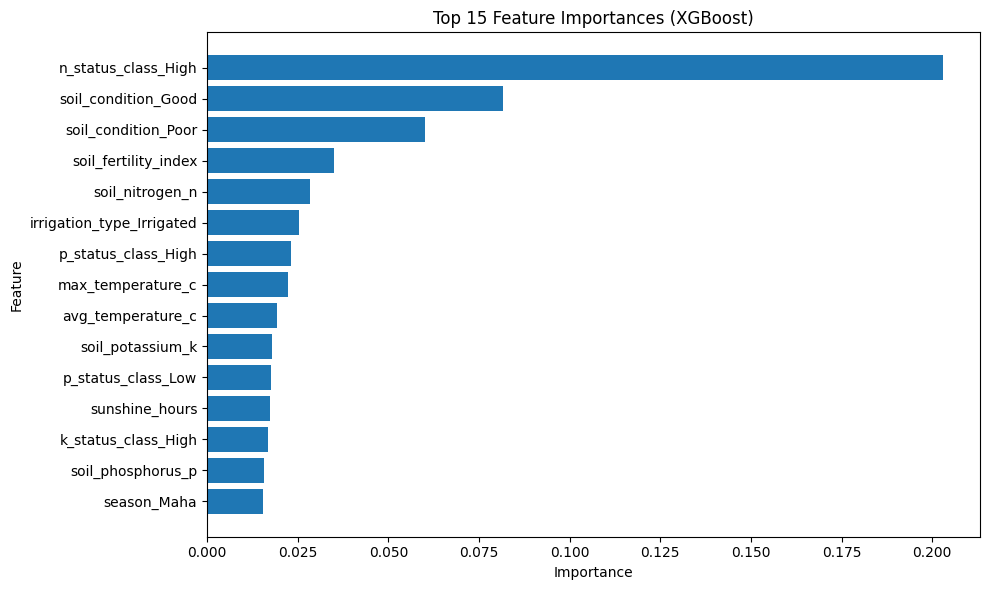

In [52]:
import matplotlib.pyplot as plt

top_n = 15
top_fi = fi.head(top_n).iloc[::-1]  # reverse for nice plotting

plt.figure(figsize=(10, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



> ***Check where rainfall + seed_variety features are ranked (Top 50 view)***



In [53]:
# Show top 50
fi.head(50)

,feature,importance
63,n_status_class_High,0.203004
54,soil_condition_Good,0.081620
56,soil_condition_Poor,0.060021
12,soil_fertility_index,0.035114
9,soil_nitrogen_n,0.028445
57,irrigation_type_Irrigated,0.025342
66,p_status_class_High,0.023271
5,max_temperature_c,0.022292
4,avg_temperature_c,0.019170
11,soil_potassium_k,0.017977


In [54]:
fi[fi["feature"].str.contains("rainfall|seed_variety", case=False, na=False)].head(30)

,feature,importance
43,seed_variety_GT 709,0.009840
42,seed_variety_GT 200,0.007525
3,seasonal_rainfall_mm,0.007481
46,seed_variety_Pacific 808,0.006597
44,seed_variety_Jet 999,0.006596
45,seed_variety_Local Variety,0.006576
41,seed_variety_Commando,0.005968
2,rainfall_30d_mm,0.005606
61,rainfall_condition_Low,0.005572
62,rainfall_condition_Normal,0.005177




> ***Group importance by original column***



In [55]:
# Map each encoded feature back to its original column name
def base_feature_name(feat: str) -> str:
    for c in cat_cols:
        prefix = c + "_"
        if feat.startswith(prefix):
            return c
    return feat  # numeric stays same

fi["base_feature"] = fi["feature"].apply(base_feature_name)

group_imp = (
    fi.groupby("base_feature")["importance"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

group_imp.head(20)

,base_feature,importance
0,n_status_class,0.218873
1,soil_condition,0.146760
2,location,0.119314
3,soil_type,0.051827
4,p_status_class,0.047883
5,irrigation_type,0.044569
6,seed_variety,0.043102
7,soil_fertility_index,0.035114
8,k_status_class,0.032548
9,district,0.031104




> ***Plot grouped importance***



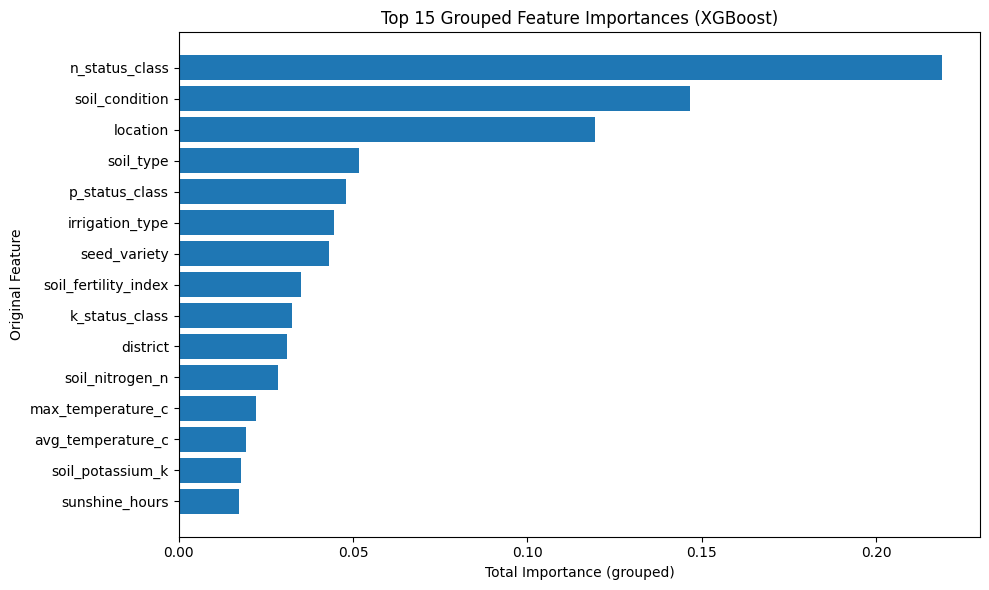

In [56]:
import matplotlib.pyplot as plt

top_n = 15
tmp = group_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(tmp["base_feature"], tmp["importance"])
plt.title("Top 15 Grouped Feature Importances (XGBoost)")
plt.xlabel("Total Importance (grouped)")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

In [57]:
fi[fi["base_feature"] == "seed_variety"].head(20)

,feature,importance,base_feature
43,seed_variety_GT 709,0.009840,seed_variety
42,seed_variety_GT 200,0.007525,seed_variety
46,seed_variety_Pacific 808,0.006597,seed_variety
44,seed_variety_Jet 999,0.006596,seed_variety
45,seed_variety_Local Variety,0.006576,seed_variety
41,seed_variety_Commando,0.005968,seed_variety


*Top-15 shows individual encoded features. Since seed_variety is one-hot encoded, its influence is split across multiple columns, so it may not appear in Top-15. When I group importances by original column, seed variety and rainfall influence become visible.*


# Save Best Model (XGBoost pipeline)

In [58]:
#Save pipeline

import joblib
joblib.dump(xgb_pipe, "best_yield_model_xgb.pkl")
print("Saved: best_yield_model_xgb.pkl")

Saved: best_yield_model_xgb.pkl


In [59]:
#Download
from google.colab import files
files.download("best_yield_model_xgb.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>